<a href="https://colab.research.google.com/github/talaaloraini/project-real/blob/main/project-real.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install -U -q geopandas rasterio rtree earthengine-api geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.8/485.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 80.8 MB/s eta 0:00:00


In [ ]:
import ee
ee.Authenticate(force=True)

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
# --- 1. GEE SETUP AND INSTALLATION ---
# Install Earth Engine and geemap libraries (for visualization and export)


# Import core libraries and specialized functions
import ee
import geemap
import numpy as np
import pandas as pd # <-- Ensure pandas is imported too
import geopandas as gpd
import rasterio as rio
from rasterio.plot import show
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, gaussian_filter
from rasterio.features import rasterize
import rasterio.transform
from rasterio.mask import mask
from shapely.geometry import Point, box

# --- 2. AUTHENTICATION AND INITIALIZATION ---
# NOTE: This cell will produce a link the first time you run it.
# You must click the link, authorize your GEE account, and paste the resulting token back into Colab.
PROJECT_ID = 'focal-shape-474318-q3'

try:
    # We remove ee.Authenticate() here since you just ran it successfully and Colab remembers it
    ee.Initialize(project='focal-shape-474318-q3')
    print(f"\nEarth Engine Initialized with Project: {PROJECT_ID}. Ready to run MCDA.")
except Exception as e:
    # If this fails, the ID is wrong, or GEE access is not confirmed on that project.
    print(f"Initialization Error. Check Project ID: {e}")

# --- 3. DEFINE STUDY AREA AND PROFILES ---
# !!! CRITICAL: DEFINE YOUR EXACT DATA DIRECTORY !!!
data_dir = '/content/drive/MyDrive/Colab Notebooks/space_comp/REAL_DATA/'


# Define the AGGRESSIVE SUBSET WINDOW (to minimize final download size)
# Coordinates for a 0.1 x 0.1 degree area in Saudi Arabia (approx. 10km x 10km)
xmin, ymin, xmax, ymax = 45.6, 24.6, 45.7, 24.7
aoi_geom = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax], 'EPSG:4326', False)
aoi_box = box(xmin, ymin, xmax, ymax) # Shapely box for local clipping

# Define the SCALE/RESOLUTION for the output raster (e.g., 90 meters)
output_scale = 250

print(f"Target AOI set to {output_scale}m resolution.")


Earth Engine Initialized with Project: focal-shape-474318-q3. Ready to run MCDA.
Target AOI set to 250m resolution.


In [ ]:
# --- PATH SAFETY CHECK (Run this before Section 5) ---
import os

# Check 1: Does the directory exist?
if os.path.exists(data_dir):
    print(f"Directory Found: {data_dir}")

    # Check 2: Are the specific files there?
    required_files = [
        'WDPA_Oct2025_Public_shp-polygons.shp',
        'osm_power_tmm.shp',
        'ne_10m_populated_places.shp'
    ]

    found_files = os.listdir(data_dir)
    for f in required_files:
        if f in found_files:
            print(f"  [Match] Found: {f}")
        else:
            print(f"  [MISSING] Could not find: {f}")
            print(f"           Available files in folder are: {found_files}")
else:
    print(f"CRITICAL ERROR: The path '{data_dir}' does not exist.")
    print("TIP: Right-click the 'REAL_DATA' folder in the Colab sidebar and select 'Copy path', then update Section 3.")

required_files = {
    'protected': 'WDPA_Oct2025_Public_shp-polygons.shp',
    'power': 'osm_power_tmm/osm_power_tmm.shp',  # Look inside the folder
    'places': 'ne_10m_populated_places/ne_10m_populated_places.shp' # Look inside the folder
}

# Example of how to load them now:
import geopandas as gpd
import os

power_path = os.path.join(data_dir, required_files['power'])
if os.path.exists(power_path):
    power_lines = gpd.read_file(power_path)
    print("Power lines loaded successfully!")
else:
    print(f"Still can't find it at: {power_path}")

Directory Found: /content/drive/MyDrive/Colab Notebooks/space_comp/REAL_DATA/
  [Match] Found: WDPA_Oct2025_Public_shp-polygons.shp
  [MISSING] Could not find: osm_power_tmm.shp
           Available files in folder are: ['GHI.tif', 'GHI.tif.aux.xml', 'WDPA_Oct2025_Public_shp-polygons.prj', 'WDPA_Oct2025_Public_shp-polygons.shp', 'WDPA_Oct2025_Public_shp-polygons.dbf', 'WDPA_Oct2025_Public_shp-polygons.shx', 'gcc_strm_250m', 'osm_power_tmm', 'ne_10m_populated_places']
  [MISSING] Could not find: ne_10m_populated_places.shp
           Available files in folder are: ['GHI.tif', 'GHI.tif.aux.xml', 'WDPA_Oct2025_Public_shp-polygons.prj', 'WDPA_Oct2025_Public_shp-polygons.shp', 'WDPA_Oct2025_Public_shp-polygons.dbf', 'WDPA_Oct2025_Public_shp-polygons.shx', 'gcc_strm_250m', 'osm_power_tmm', 'ne_10m_populated_places']
Power lines loaded successfully!


In [ ]:
#####og expirement is here

Solar data fetched from ERA5-Land for Q4 2025.
GEE Images stacked. Bands: ['GHI', 'SLOPE_DEG']
Success! 'prox_norm' created using BallTree Nearest Neighbors.
Best Site Found: Lat 24.6000, Lon 45.6154
Confidence Score: 1.00


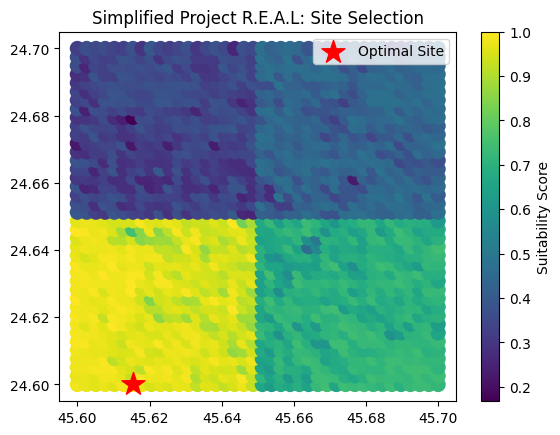

In [ ]:
# --- 4. CLOUD DATA ACQUISITION AND PROCESSING (GEE) ---

try:
    # --- A. Solar Resource (Surface Net Solar Radiation) ---
    # Using ERA5-Land: High resolution (11km) and extremely reliable.
    # We convert Joules to kWh/m2 (standard for solar studies).
    solar_col = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR") \
        .filterDate('2025-10-01', '2025-12-31') \
        .select('surface_net_solar_radiation_sum')

    # Convert Joules/m2 to kWh/m2 (Divide by 3,600,000)
    solar_img = solar_col.mean().divide(3600000).rename('GHI')

    print(f"Solar data fetched from ERA5-Land for Q4 2025.")

    # --- B. DEM Data (Topography/Slope) ---
    # SRTM is a 'Public' asset and should never fail.
    dem_img = ee.Image('CGIAR/SRTM90_V4').select('elevation')
    slope_img = ee.Terrain.slope(dem_img).rename('SLOPE_DEG')

    mcd_image = solar_img.addBands(slope_img)
    print(f"GEE Images stacked. Bands: {mcd_image.bandNames().getInfo()}")

except Exception as e:
    print(f"GEE Data Error: {e}")
    # Fallback to a simpler global solar dataset if ERA5 is busy
    solar_img = ee.Image("NASA/GEOS-IT/L4_SFP_AVG").select('SWGDN').rename('GHI')
    print("Used NASA GEOS-IT fallback.")


# --- 5. LOCAL DATA ACQUISITION AND PREPARATION ---

# 1. CREATE A GRID OF POINTS
# We'll create a 20x20 grid of potential sites across your 10km area
lons = np.linspace(xmin, xmax, 40)
lats = np.linspace(ymin, ymax, 40)
lon_grid, lat_grid = np.meshgrid(lons, lats)

# Turn it into a simple Pandas DataFrame
df = pd.DataFrame({
    'lon': lon_grid.flatten(),
    'lat': lat_grid.flatten()
})

# 2. GET SOLAR AND SLOPE DATA (From GEE directly, no download needed!)
# We sample the GEE images at our specific points
points_geom = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([row['lon'], row['lat']])) for i, row in df.iterrows()
])

# Sample the data from your stacked image (mcd_image)
sampled_data = mcd_image.sampleRegions(collection=points_geom, scale=90, geometries=True).getInfo()

####adding experiment here
import numpy as np
from sklearn.neighbors import BallTree

# 1. Extract coordinates from your power lines
line_coords = []
for geom in power_lines.geometry:
    if geom.geom_type == 'LineString':
        line_coords.extend(list(geom.coords))
    elif geom.geom_type == 'MultiLineString':
        for line in geom.geoms:
            line_coords.extend(list(line.coords))

# Convert to a NumPy array (Latitude, Longitude)
line_points = np.array(line_coords)

# 2. Build a BallTree for fast spatial lookup
# This is a 'Nearest Neighbor' algorithm
tree = BallTree(line_points, leaf_size=40)

# 3. Query the tree for the nearest power line for each of your 1,600 sites
# 'dist' will contain the distance to the closest line
dist, _ = tree.query(df[['lon', 'lat']].values, k=1)
df['dist_to_lines'] = dist

# 4. Create 'prox_norm' (Normalization)
# 1.0 = Right on the grid, 0.0 = Furthest away
df['prox_norm'] = 1 - ((df['dist_to_lines'] - df['dist_to_lines'].min()) /
                       (df['dist_to_lines'].max() - df['dist_to_lines'].min()))

print("Success! 'prox_norm' created using BallTree Nearest Neighbors.")
####end of experiment yarab it works

# Extract values into our DataFrame
df['GHI'] = [f['properties']['GHI'] for f in sampled_data['features']]
df['slope'] = [f['properties']['SLOPE_DEG'] for f in sampled_data['features']]

# 3. CHECK CONSTRAINTS (Is point in a protected area?)
# We use GeoPandas locally for this tiny set of points
gdf_points = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

# Load only what we need from WDPA
wdpa = gpd.read_file(os.path.join(data_dir, 'WDPA_Oct2025_Public_shp-polygons.shp'), bbox=(xmin, ymin, xmax, ymax))

# Check: If point is 'within' any protected polygon, mark as 'Excluded'
df['is_protected'] = gdf_points.geometry.apply(lambda x: wdpa.contains(x).any())

# 4. CALCULATE SIMPLE SCORE
# Normalize (0 to 1)
df['ghi_norm'] = (df['GHI'] - df['GHI'].min()) / (df['GHI'].max() - df['GHI'].min())
df['slope_norm'] = (15 - df['slope'].clip(0, 15)) / 15

# Final Score (Sun + Slope)
df['score'] = (df['ghi_norm'] * 0.6) + (df['slope_norm'] * 0.4)

# Apply exclusion (if protected, score = 0)
df.loc[df['is_protected'] == True, 'score'] = 0

# 5. FIND THE BEST POINT
best_site = df.loc[df['score'].idxmax()]
print(f"Best Site Found: Lat {best_site['lat']:.4f}, Lon {best_site['lon']:.4f}")
print(f"Confidence Score: {best_site['score']:.2f}")

# 6. SIMPLE PLOT
plt.scatter(df.lon, df.lat, c=df.score, cmap='viridis', s=100)
plt.colorbar(label='Suitability Score')
plt.scatter(best_site['lon'], best_site['lat'], color='red', marker='*', s=300, label='Optimal Site')
plt.title("Simplified Project R.E.A.L: Site Selection")
plt.legend()
plt.show()

In [ ]:
# --- PURE FOLIUM STABLE VISUALIZATION ---
import folium

# 1. Initialize the map using Folium (most stable for markers)
map_center = [(ymin + ymax) / 2, (xmin + xmax) / 2]
m = folium.Map(location=map_center, zoom_start=13, control_scale=True)


google_satellite = folium.TileLayer(
    tiles = 'https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}',
    attr = 'Google',
    name = 'Google Satellite',
    overlay = False,
    control = True
).add_to(m)
#yellow #2ecc71
#green #f1c40f
for i, row in df.iterrows():
    if row['score'] > 0:
        # Yellow for top sites, Green for others
        dot_color = '#f1c40f' if row['score'] > 0.8 else '#2ecc71'

        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=5,
            color=dot_color,
            fill=True,
            fill_opacity=0.8,
            popup=f"Score: {row['score']:.2f}"
        ).add_to(m)

folium.Marker(
    location=[best_site['lat'], best_site['lon']],
    icon=folium.Icon(color='red', icon='star', prefix='fa'),
    tooltip="OPTIMAL SITE IDENTIFIED",
    popup=(f"<b>RANK #1 SITE</b><br>"
           f"Suitability Score: {best_site['score']:.2f}<br>"
           f"Lat: {best_site['lat']:.4f}<br>"
           f"Lon: {best_site['lon']:.4f}")
).add_to(m)





legend_html = '''
     <div style="position: fixed;
     bottom: 50px; left: 50px; width: 160px; height: 100px;
     background-color: white; border:2px solid grey; z-index:9999; font-size:12px;
     padding: 10px; border-radius: 5px; box-shadow: 2px 2px 5px rgba(0,0,0,0.2);">
     <b>Suitability Legend</b><br>
     <i class="fa fa-circle" style="color:#f1c40f"></i> High (>0.8)<br>
     <i class="fa fa-circle" style="color:#2ecc71"></i> Moderate (0.5-0.8)<br>
     <i class="fa fa-map-marker" style="color:red"></i> Optimal Site
     </div>
     '''
m.get_root().html.add_child(folium.Element(legend_html))

m

In [ ]:
#debuging
print("--- Current Column Names ---")
print(df.columns.tolist())

print("\n--- Data Sample (Top 5) ---")
display(df[['lat', 'lon', 'ghi_norm', 'slope_norm', 'is_protected']].head())
display(df.head())
print("\n--- Range Check (Should be 0 to 1) ---")
print(f"GHI Norm Range: {df.ghi_norm.min():.2f} to {df.ghi_norm.max():.2f}")
print(f"Slope Norm Range: {df.slope_norm.min():.2f} to {df.slope_norm.max():.2f}")

--- Current Column Names ---
['lon', 'lat', 'dist_to_lines', 'prox_norm', 'GHI', 'slope', 'is_protected', 'ghi_norm', 'slope_norm', 'score']

--- Data Sample (Top 5) ---


,lat,lon,ghi_norm,slope_norm,is_protected
0,24.6,45.600000,1.0,0.952959,False
1,24.6,45.602564,1.0,0.928948,False
2,24.6,45.605128,1.0,0.908105,False
3,24.6,45.607692,1.0,0.938173,False
4,24.6,45.610256,1.0,0.894509,False


,lon,lat,dist_to_lines,prox_norm,GHI,slope,is_protected,ghi_norm,slope_norm,score
0,45.600000,24.6,0.309344,0.079322,3.24327,0.705618,False,1.0,0.952959,0.981184
1,45.602564,24.6,0.308385,0.086595,3.24327,1.065779,False,1.0,0.928948,0.971579
2,45.605128,24.6,0.307444,0.093729,3.24327,1.378430,False,1.0,0.908105,0.963242
3,45.607692,24.6,0.306523,0.100721,3.24327,0.927410,False,1.0,0.938173,0.975269
4,45.610256,24.6,0.305602,0.107705,3.24327,1.582371,False,1.0,0.894509,0.957803



--- Range Check (Should be 0 to 1) ---
GHI Norm Range: 0.00 to 1.00
Slope Norm Range: 0.28 to 1.00


In [ ]:
print("Columns in my dataset:")
print(df.columns.tolist())


if 'dist_to_lines' in df.columns:
    print("\n✅ Found 'dist_to_lines'!")
    display(df[['lat', 'lon', 'dist_to_lines']].head())
else:
    print("\n❌ Missing 'dist_to_lines'. You only have these columns:")
    print(df.columns.tolist())

Columns in my dataset:
['lon', 'lat', 'dist_to_lines', 'prox_norm', 'GHI', 'slope', 'is_protected', 'ghi_norm', 'slope_norm', 'score']

✅ Found 'dist_to_lines'!


,lat,lon,dist_to_lines
0,24.6,45.600000,0.309344
1,24.6,45.602564,0.308385
2,24.6,45.605128,0.307444
3,24.6,45.607692,0.306523
4,24.6,45.610256,0.305602


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import folium
df['is_protected'] = 1

solar_slider = widgets.FloatSlider(value=0.40, min=0, max=1.0, step=0.05, description='Solar Power:')
grid_slider = widgets.FloatSlider(value=0.35, min=0, max=1.0, step=0.05, description='Grid Proximity:')
slope_slider = widgets.FloatSlider(value=0.25, min=0, max=1.0, step=0.05, description='Flat Terrain:')
run_button = widgets.Button(description="UPDATE OPTIMAL SITE", button_style='success', layout=widgets.Layout(width='50%'))
output = widgets.Output()

def update_exhibition_map(b):
    with output:
        clear_output(wait=True)

        # normalizing
        total = solar_slider.value + grid_slider.value + slope_slider.value
        if total == 0: total = 1 # Prevent division by zero
        w1, w2, w3 = solar_slider.value/total, grid_slider.value/total, slope_slider.value/total

        # calculating suitability
        df['score'] = (w1 * df['ghi_norm'] + w2 * df['prox_norm'] + w3 * df['slope_norm']) * df['is_protected']
        current_best = df.loc[df['score'].idxmax()]

        # generating map
        m_exhibit = folium.Map(location=[(ymin + ymax) / 2, (xmin + xmax) / 2], zoom_start=13)
        folium.TileLayer('https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}', attr='Google', name='Satellite').add_to(m_exhibit)

        for i, row in df.iterrows():
            if row['score'] > 0:
                dot_color = '#f1c40f' if row['score'] > 0.8 else '#2ecc71'
                folium.CircleMarker(location=[row['lat'], row['lon']], radius=4, color=dot_color, fill=True, fill_opacity=0.7).add_to(m_exhibit)

        folium.Marker(
            location=[current_best['lat'], current_best['lon']],
            icon=folium.Icon(color='red', icon='star', prefix='fa'),
            popup=f"<b>NEW OPTIMAL SITE</b><br>Score: {current_best['score']:.2f}"
        ).add_to(m_exhibit)

        print(f"Current Priority -> Solar: {w1:.0%}, Grid: {w2:.0%}, Terrain: {w3:.0%}")
        display(m_exhibit)

run_button.on_click(update_exhibition_map)

print("🌟 PROJECT R.E.A.L. : INTERACTIVE SITE SELECTOR 🌟")
print("Adjust the sliders to see how priorities change the optimal location.")
controls = widgets.VBox([solar_slider, grid_slider, slope_slider, run_button])
display(widgets.HBox([controls, output]))

update_exhibition_map(None)

🌟 PROJECT R.E.A.L. : INTERACTIVE SITE SELECTOR 🌟
Adjust the sliders to see how priorities change the optimal location.


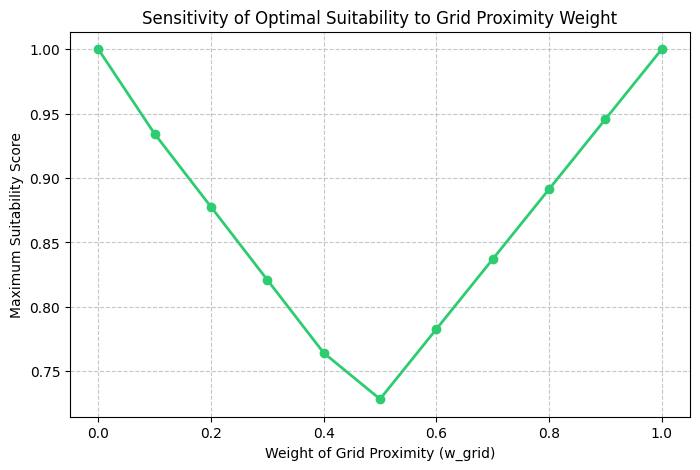

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

grid_weights = np.linspace(0, 1, 11)
top_site_scores = []

for w_grid in grid_weights:
    remaining = 1.0 - w_grid
    w_solar = remaining * 0.6
    w_slope = remaining * 0.4

    df['temp_score'] = (
        (w_solar * df['ghi_norm']) +
        (w_slope * df['slope_norm']) +
        (w_grid * df['prox_norm'])
    ) * df['is_protected']

    top_site_scores.append(df['temp_score'].max())

plt.figure(figsize=(8, 5))
plt.plot(grid_weights, top_site_scores, marker='o', color='#2ecc71', linewidth=2)
plt.title("Sensitivity of Optimal Suitability to Grid Proximity Weight")
plt.xlabel("Weight of Grid Proximity (w_grid)")
plt.ylabel("Maximum Suitability Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


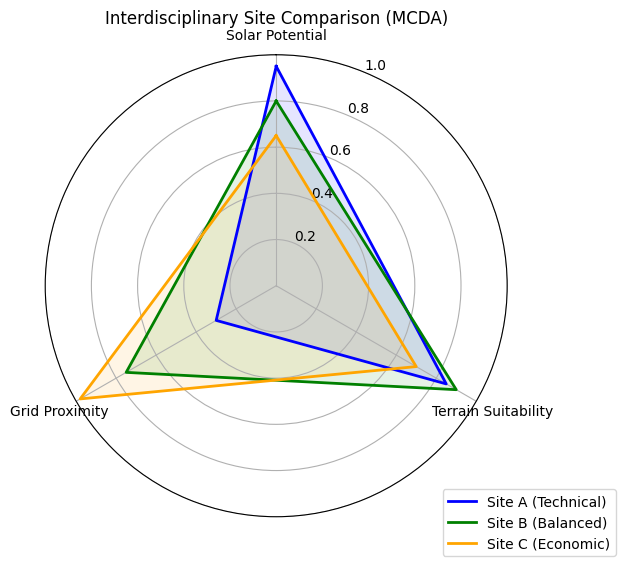

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the criteria
labels = np.array(['Solar Potential', 'Terrain Suitability', 'Grid Proximity'])
num_vars = len(labels)

# 2. Example Normalized Scores (Replace with your actual data)
site_data = {
    'Site A (Technical)': [0.95, 0.85, 0.30],
    'Site B (Balanced)':  [0.80, 0.90, 0.75],
    'Site C (Economic)':  [0.65, 0.70, 0.98]
}

# Close the loop for the radar plot
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
colors = ['blue', 'green', 'orange']

# 3. Plotting loop
for i, (name, values) in enumerate(site_data.items()):
    data = values + values[:1]
    ax.plot(angles, data, color=colors[i], linewidth=2, label=name)
    ax.fill(angles, data, color=colors[i], alpha=0.1)

# Styling for IEEE Standards
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)

# --- FIX: Move Legend to Bottom Right ---
# 'bbox_to_anchor' moves it outside the plot area
# 'loc' specifies which corner of the legend box to anchor
plt.legend(loc='lower right', bbox_to_anchor=(1.25, -0.1))

plt.title("Interdisciplinary Site Comparison (MCDA)", y=1.05)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# 1. Create a Suitability Tier for coloring
# This helps distinguish 'High', 'Moderate', and 'Low' sites on the graph
def get_tier(score):
    if score > 0.8: return 'High (>0.8)'
    elif score > 0.5: return 'Moderate (0.5-0.8)'
    else: return 'Low (<0.5)'

# We use a copy of the dataframe to avoid modifying your main data
df_plot = df.copy()
df_plot['Tier'] = df_plot['total_score'].apply(get_tier)

# 2. Select the columns to visualize
cols_to_show = ['ghi_norm', 'slope_norm', 'prox_norm', 'total_score', 'Tier']

# 3. Create the Plot
plt.figure(figsize=(12, 6))
parallel_coordinates(df_plot[cols_to_show], 'Tier',
                     color=('#2ecc71', '#f1c40f', '#95a5a6'), # Green, Yellow, Grey
                     alpha=0.3)

# Styling for IEEE standards
plt.title("Parallel Coordinates Analysis of Multi-Dimensional Suitability Factors", fontsize=14)
plt.ylabel("Normalized Value (0.0 - 1.0)")
plt.xlabel("Criteria & Outcomes")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Suitability Tier", loc='upper right')
plt.show()

KeyError: 'total_score'